> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 10: Classification Trees with SF Rent Data

## Outline

- Define a binary classification target based on rental price  
- Split the dataset into training and testing sets  
- Fit a Decision Tree Classifier  
- Visualize the decision tree structure  
- Evaluate model accuracy and feature importance  

In this lab, we’ll build a classification model to predict whether a rental listing in San Francisco is considered **"affordable"** based on its features.

We are continuing with the **SF Rent dataset** used in **Lab 9**, and will explore how classification trees can uncover patterns in rental prices.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_10_classification.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Overview

**Dataset:** `rent.csv`  
Source: [TidyTuesday-2022-7-05](https://github.com/rfordatascience/tidytuesday/blob/main/data/2022/2022-07-05/rent.csv)

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | 1 = room in apartment |
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |

## Part 1: Clean and Prepare the Data

We'll repeat the cleaning process from Lab 9, including:
- Removing duplicates
- Dropping missing values in key columns
- Filtering out extreme outliers
- Converting data types

### Why This Matters:
Good models depend on clean, reliable inputs.


In [1]:
import pandas as pd

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

# Initial check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


/var/folders/st/mxnd0j9d72v3_qdzxw5s7bq40000gn/T/ipykernel_26415/2820816543.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [2]:
# Drop duplicate listings using post_id
df = df.drop_duplicates(subset='post_id')

# Drop rows missing essential features
required_cols = ['price', 'beds', 'baths', 'sqft', 'lat', 'lon']
df = df.dropna(subset=required_cols)

# Remove outliers
df = df[df['price'].between(500, 20000)]
df = df[df['beds'].between(0, 10)]
df = df[df['baths'].between(0.5, 10)]
df = df[df['sqft'].between(100, 5000)]

# Convert columns to appropriate data types
df['beds'] = df['beds'].astype(int)
df['baths'] = df['baths'].astype(float)
df['sqft'] = df['sqft'].astype(int)
df['price'] = df['price'].astype(int)

# Reset index
df = df.reset_index(drop=True)

# Quick check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1984 entries, 0 to 1983
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   post_id      1984 non-null   object 
 1   date         1984 non-null   object 
 2   year         1984 non-null   float64
 3   nhood        1984 non-null   object 
 4   city         1984 non-null   object 
 5   county       1979 non-null   object 
 6   price        1984 non-null   int64  
 7   beds         1984 non-null   int64  
 8   baths        1984 non-null   float64
 9   sqft         1984 non-null   int64  
 10  room_in_apt  1984 non-null   float64
 11  address      1768 non-null   object 
 12  lat          1984 non-null   float64
 13  lon          1984 non-null   float64
 14  title        1855 non-null   object 
 15  descr        1847 non-null   object 
 16  details      1873 non-null   object 
dtypes: float64(5), int64(3), object(9)
memory usage: 263.6+ KB


In [3]:
# Preview data
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,4817227421,20141223,2014.0,alameda,alameda,alameda,1939,2,1.0,864,0.0,NaN,37.770600,-122.264800,"LIVE MORE, DRIVE LESS! JUST ACROSS THE BAY FRO...","Summer House Apartments 1826 Poggi St, Alameda...","2BR / 1Ba 864ft2 apartment date=""2014-12-23"" ..."
1,4710888130,20141012,2014.0,alameda,alameda,alameda,2250,2,1.0,1080,0.0,659,37.772835,-122.248585,2br Victortian Duplex Garden Apt.,"This 1903 ""Workingman's Victorian"" on a quiet ...","2BR / 1Ba 1080ft2 apartment date=""2014-11-02""..."
2,5961989126,20170126,2017.0,alameda,alameda,alameda,3995,3,2.0,1787,0.0,NaN,37.759231,-122.247190,3 BR/2 BA Queene Anne on Park St.,This charming 1787 sq ft meticulously maintain...,"3BR / 2Ba1787ft2 data-date=""2017-02-01"" data-t..."
3,4935175730,20150316,2015.0,alameda,alameda,alameda,2536,2,2.0,1225,0.0,NaN,37.753609,-122.249081,Spacious 2BR/2BA in a Great Community!,Tower Apartments CALL US: show contact infox3...,"2BR / 2Ba 1225ft2 apartment date=""2015-04-19""..."
4,4988581576,20150421,2015.0,alameda,alameda,alameda,2650,2,1.0,950,0.0,497,37.758922,-122.263314,"Upgraded 2B w/ Pool View, Short Walk to School...",Enjoy and experience the relaxing atmosphere o...,"2BR / 1Ba 950ft2 apartment date=""2015-04-20"" ..."


## Part 2: Create a Binary Target Variable

We'll classify whether a listing is **Affordable** (price < 3,000).

- 1 = Affordable
- 0 = Not Affordable

### Why This Matters:
To use classification trees, we need a target variable with a limited number of classes.


In [4]:
# Create binary target variable
df['affordable'] = (df['price'] < 3000).astype(int)

# Check target class distribution
df['affordable'].value_counts(normalize=True)


affordable
1    0.611391
0    0.388609
Name: proportion, dtype: float64

### 🔧 Do the following – Part 2

1. Adjust the affordable threshold to $5,000 and check the class balance again  
2. Calculate what percentage of listings are labeled as affordable



In [5]:
# Same rule with one number moved. $5,000 sits well above this market, so
# almost every listing lands on the affordable side of it.
df['affordable'] = (df['price'] < 5000).astype(int)

print("Class balance at $5,000 (proportion):")
print(df['affordable'].value_counts(normalize=True).to_string())
print("\nCounts:")
print(df['affordable'].value_counts().to_string())

pct_5000 = df['affordable'].mean() * 100
pct_3000 = (df['price'] < 3000).mean() * 100
print(f"\n{pct_5000:.2f}% of listings are labeled affordable at $5,000.")
print(f"{pct_3000:.2f}% of listings are labeled affordable at $3,000.")

# Class balance is not trivia here. A model that ignores its inputs and always
# guesses the bigger class scores whatever that class's share is.
print(f"\nGuessing 'Affordable' every time would score {pct_5000:.1f}% at the "
      f"$5,000 threshold and {pct_3000:.1f}% at $3,000.")

Class balance at $5,000 (proportion):
affordable
1    0.917339
0    0.082661

Counts:
affordable
1    1820
0     164

91.73% of listings are labeled affordable at $5,000.
61.14% of listings are labeled affordable at $3,000.

Guessing 'Affordable' every time would score 91.7% at the $5,000 threshold and 61.1% at $3,000.


Reset the threshold to $3000

In [6]:
# Reset binary target back to 3000
df['affordable'] = (df['price'] < 3000).astype(int)

## Part 3: Select Features and Split Data

We'll use property characteristics as predictors:
- `beds`, `baths`, `sqft`

Then split the data into 80% training and 20% testing.

### Why This Matters:
Train/test splitting ensures our model is evaluated on unseen data.

In [7]:
from sklearn.model_selection import train_test_split

# Select features and target
X = df[['beds', 'baths', 'sqft']]
y = df['affordable']

# Create train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check dimensions
X_train.shape, X_test.shape


((1587, 3), (397, 3))

In [8]:
# Testing the part 3 reflection instead of guessing at it. The target was built
# out of price, so handing price back to the model isn't really a fair question.
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score

X_leak = df[['beds', 'baths', 'sqft', 'price']]
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leak, y, test_size=0.2, random_state=42
)

# One level deep is all it needs.
leak = DecisionTreeClassifier(max_depth=1, random_state=42).fit(Xl_train, yl_train)

print(f"Test accuracy with price as a predictor, depth 1: "
      f"{accuracy_score(yl_test, leak.predict(Xl_test)):.4f}")
print("\nThe entire tree:")
print(export_text(leak, feature_names=list(X_leak.columns)))
print("Feature importance:",
      dict(zip(X_leak.columns, leak.feature_importances_.round(3))))

Test accuracy with price as a predictor, depth 1: 1.0000

The entire tree:
|--- price <= 2997.50
|   |--- class: 1
|--- price >  2997.50
|   |--- class: 0

Feature importance: {'beds': np.float64(0.0), 'baths': np.float64(0.0), 'sqft': np.float64(0.0), 'price': np.float64(1.0)}


### 🔧 Reflection - Part 3: 
1. What would be the impact if we added `price` as an independent variable?

### ✍️ Your Response: 🔧

**1.** It would hand the model the answer sheet. `affordable` is just `price < 3000`, so price isn't a predictor here at all, it's the label with a different name on it.

I ran it to see. One split, `price <= 2997.50`, and it scores a perfect 1.0000 on the test set at depth 1. beds, baths and sqft all fall to zero importance. Nothing left for them to explain.

That's target leakage, and the perfect score is what makes it easy to miss. It reads like a breakthrough when the tree is really just reading the label off its own input. It would also be useless on the job, because the whole reason you'd ask whether a unit is affordable is that you don't have a price for it yet.

## Part 4: Build and Fit the Decision Tree Classifier

We'll train a `DecisionTreeClassifier` on our data.

### Why This Matters:
Decision trees make predictions by splitting data into branches using rules that reduce impurity.


In [9]:
from sklearn.tree import DecisionTreeClassifier

# Initialize classifier
clf = DecisionTreeClassifier(random_state=42)

# Train model on training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Visualize the tree
Pay close attention to how wide and deep the branches reach

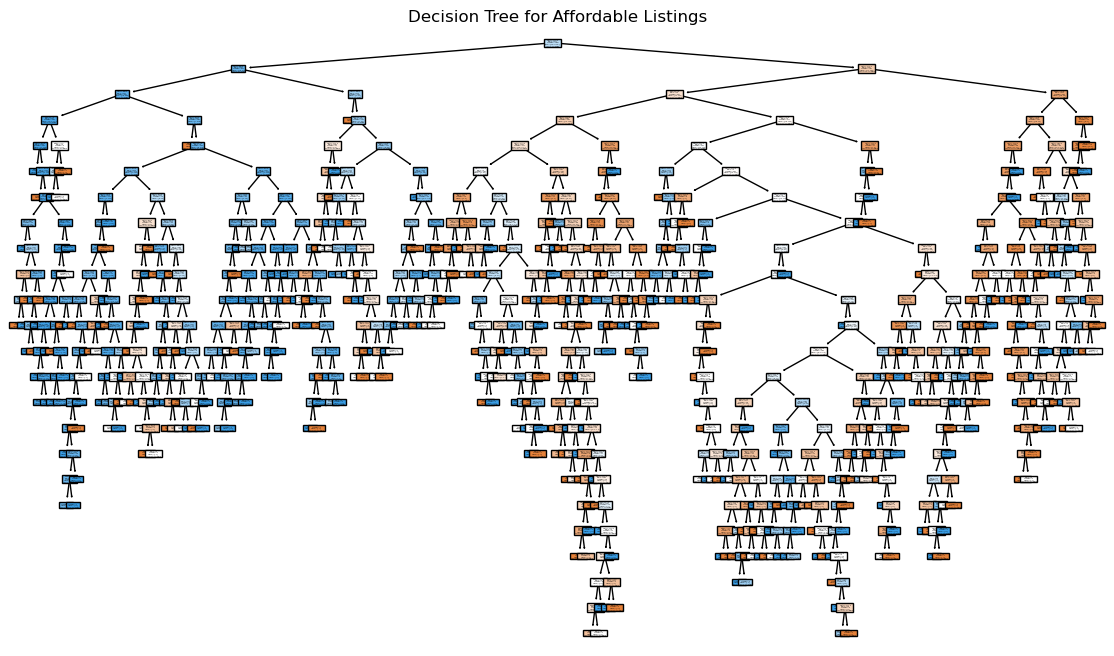

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot decision tree
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=X.columns, class_names=['Not Affordable', 'Affordable'], filled=True)
plt.title("Decision Tree for Affordable Listings")
plt.show()


### 🔧 Do the following – Part 4

1. Create a second model called `clf_limited` with `max_depth=3`  
2. Fit it on the same training data 
3. Visualize this new tree  
> You’ll compare the accuracy of this smaller tree in the next section


clf          depth 23   leaves 423
clf_limited  depth  3   leaves   8


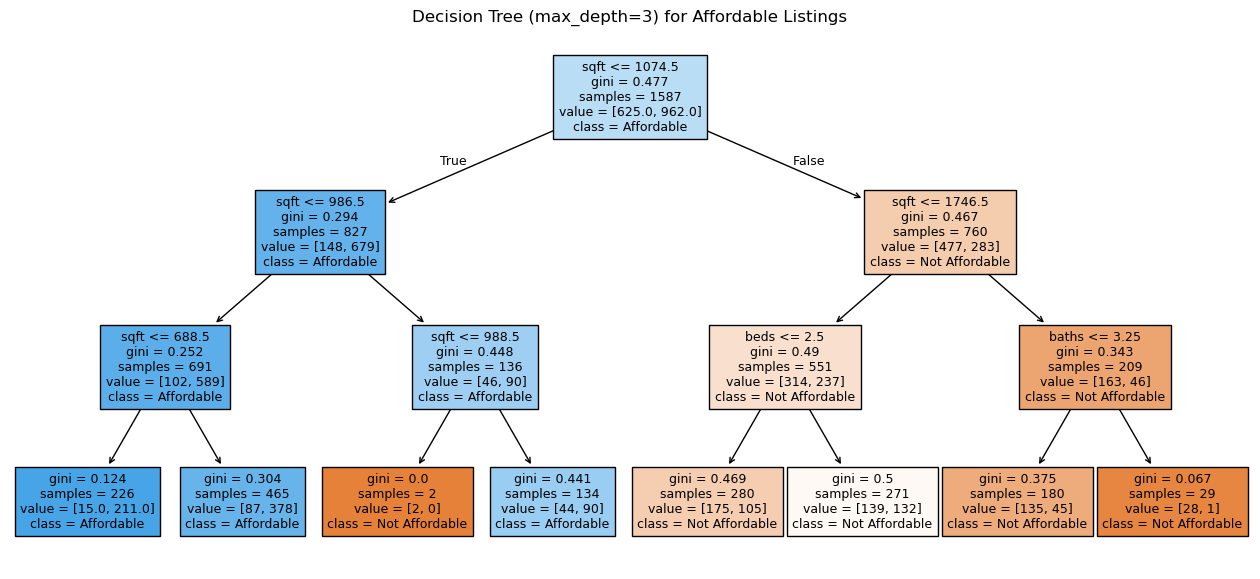

In [11]:
# Same training data and the same seed, with one constraint: stop after three
# levels. Everything different between the two models comes from that.
clf_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_limited.fit(X_train, y_train)

print(f"clf          depth {clf.get_depth():2d}   leaves {clf.get_n_leaves():3d}")
print(f"clf_limited  depth {clf_limited.get_depth():2d}   leaves {clf_limited.get_n_leaves():3d}")

plt.figure(figsize=(16, 7))
plot_tree(clf_limited, feature_names=X.columns,
          class_names=['Not Affordable', 'Affordable'], filled=True, fontsize=9)
plt.title("Decision Tree (max_depth=3) for Affordable Listings")
plt.show()

## 5. Evaluate the Model

We’ll check how well the tree performed on the test data using:
- Accuracy score
- Confusion matrix

### Why This Matters:
We want to know how often the model is right and what kind of mistakes it makes.


In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict on test set
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.6952141057934509
Confusion Matrix:
 [[ 91  55]
 [ 66 185]]


### 🔧 Do the following – Part 5

1. Use the `clf_limited` model you created in Part 4 to predict on the test set  
2. Calculate and print the **test accuracy** for `clf_limited`

In [13]:
# The smaller tree, scored on the same held-out listings.
y_pred_limited = clf_limited.predict(X_test)
acc_limited = accuracy_score(y_test, y_pred_limited)

print(f"clf          test accuracy: {acc:.4f}")
print(f"clf_limited  test accuracy: {acc_limited:.4f}")

moved = int(round(abs(acc_limited - acc) * len(y_test)))
print(f"\nDifference: {acc_limited - acc:+.4f}, which is {moved} listings out of {len(y_test)}.")

print("\nConfusion matrix, clf_limited:")
print(confusion_matrix(y_test, y_pred_limited))

clf          test accuracy: 0.6952
clf_limited  test accuracy: 0.7078

Difference: +0.0126, which is 5 listings out of 397.

Confusion matrix, clf_limited:
[[111  35]
 [ 81 170]]


In [14]:
# A 1.3 point gap on 397 listings is thin enough to be luck, so two checks here:
# where the full tree starts memorizing, and whether depth 3 keeps winning once
# the train/test split moves.
import numpy as np

print(f"{'max_depth':>10} {'leaves':>7} {'train':>8} {'test':>8}")
for d in [1, 2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    print(f"{str(d):>10} {m.get_n_leaves():7d} "
          f"{accuracy_score(y_train, m.predict(X_train)):8.4f} "
          f"{accuracy_score(y_test, m.predict(X_test)):8.4f}")

gaps = []
for seed in range(30):
    a, b, c, d2 = train_test_split(X, y, test_size=0.2, random_state=seed)
    full = DecisionTreeClassifier(random_state=42).fit(a, c)
    small = DecisionTreeClassifier(max_depth=3, random_state=42).fit(a, c)
    gaps.append(accuracy_score(d2, small.predict(b)) - accuracy_score(d2, full.predict(b)))

print(f"\nAcross 30 different train/test splits, depth 3 beat the full tree "
      f"{sum(g > 0 for g in gaps)} times out of 30.")
print(f"Mean gap {np.mean(gaps) * 100:+.2f} points, standard deviation {np.std(gaps) * 100:.2f}.")
print(f"\nFor scale: always guessing 'Affordable' scores "
      f"{max(y_test.mean(), 1 - y_test.mean()):.4f} on this test set.")

 max_depth  leaves    train     test
         1       2   0.7284   0.7103
         2       4   0.7284   0.7103
         3       8   0.7297   0.7078
         5      27   0.7417   0.6952
        10     176   0.8110   0.6826
      None     423   0.9023   0.6952



Across 30 different train/test splits, depth 3 beat the full tree 24 times out of 30.
Mean gap +2.38 points, standard deviation 2.59.

For scale: always guessing 'Affordable' scores 0.6322 on this test set.


### Reflection: 
1. Compare the test accuracy of `clf_limited` to the original `clf`. Which performs better?

### ✍️ Your Response: 🔧

**1.** `clf_limited` wins, 0.7078 to 0.6952. That's five listings out of 397 though, thin enough that I didn't trust it, so I reran both models on 30 different train/test splits. Depth 3 came out ahead 24 times, mean gap 2.38 points. Real, but noisy.

The why is in the training scores. The full tree gets 0.9023 on rows it has already seen and 0.6952 on rows it hasn't, a 21 point drop spread across 423 leaves. That's memorizing, not learning. `clf_limited` posts 0.7297 and 0.7078, basically the same number twice, which is what you want to see.

Neither is much to celebrate. Guessing "Affordable" for every listing scores 0.6322.

## Part 6: Evaluate the Tree Feature Importance

We’ll rank the most important predictors.

### Why This Matters:
Tree plots explain the model's logic. Feature importance shows what drives predictions.


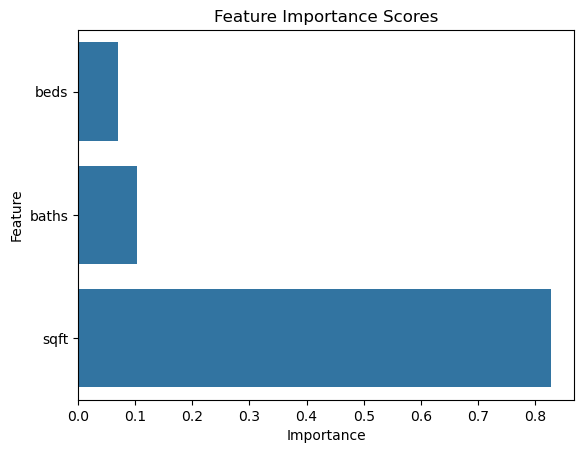

In [15]:
import seaborn as sns

# Plot feature importance
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance Scores")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


### 🔧 Do the following – Part 6

1. Evaluate the importance of features in the smaller tree, `clf_limited`   

Feature importance:
          clf  clf_limited
beds   0.0699       0.0179
baths  0.1030       0.0120
sqft   0.8272       0.9701


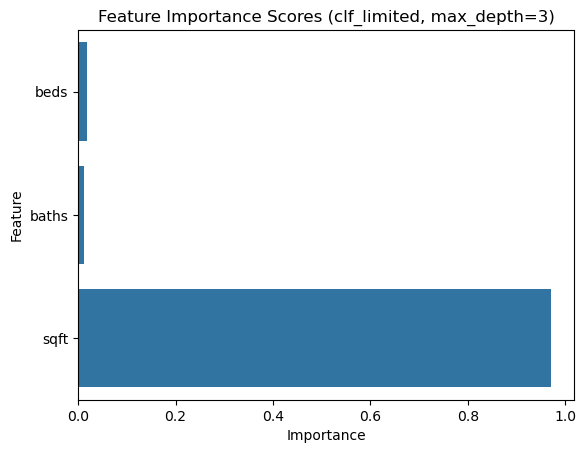

In [16]:
# The same plot for the smaller tree, with both models' numbers printed so they
# can be read side by side.
feat_imp_limited = pd.Series(clf_limited.feature_importances_, index=X.columns)

print("Feature importance:")
print(pd.DataFrame({'clf': feat_imp, 'clf_limited': feat_imp_limited}).round(4).to_string())

sns.barplot(x=feat_imp_limited.values, y=feat_imp_limited.index)
plt.title("Feature Importance Scores (clf_limited, max_depth=3)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [17]:
# Importance measures impurity reduction, not influence on the answer. beds and
# baths both score above zero here without changing a single prediction.
right_branch = X_train['sqft'] > 1074.5
print(f"Training rows on the sqft > 1074.50 side of the root: {right_branch.sum()}")
print("Every prediction the tree makes for them:",
      set(clf_limited.predict(X_train[right_branch])))
print("So the beds and baths splits below that point sort those rows into")
print("groups that all get the same answer.")

# If the lower splits change no answers, the root on its own should score as well.
one_rule = (X_test['sqft'] <= 1074.5).astype(int)
print(f"\nAccuracy of the whole depth 3 tree:                   "
      f"{accuracy_score(y_test, y_pred_limited):.4f}")
print(f"Accuracy of one rule, sqft <= 1074.50 is affordable:  "
      f"{accuracy_score(y_test, one_rule):.4f}")

Training rows on the sqft > 1074.50 side of the root: 760
Every prediction the tree makes for them: {np.int64(0)}
So the beds and baths splits below that point sort those rows into
groups that all get the same answer.

Accuracy of the whole depth 3 tree:                   0.7078
Accuracy of one rule, sqft <= 1074.50 is affordable:  0.7103


### Reflection: 
1. Which feature does the limitted tree split on first?  
2. Is the structure simpler or more complex than the original `clf` tree?

### ✍️ Your Response: 🔧

**1.** `sqft`, at `sqft <= 1074.50`. Both trees pick it for the root. In the limited tree it takes 0.9701 of the importance, leaving 0.0179 for beds and 0.0120 for baths.

**2.** Simpler, and by a lot. 8 leaves instead of 423, 3 levels instead of 23.

It's actually simpler than 8 leaves makes it sound. Look at the right half of the plot: every leaf under `sqft > 1074.50` comes back Not Affordable, so those beds and baths splits sort 760 training rows into groups that all get handed the same answer. They aren't deciding anything. I checked it by throwing the tree away and keeping one rule, `sqft <= 1074.50` means affordable, which scored 0.7103 against the real tree's 0.7078. Six of the seven splits are decoration, and on the test set they cost a listing.

In [18]:
# Evidence for part 7. Before answering I wanted to know whether beds, baths and
# sqft can separate the two classes at all, and how much rent moves inside one
# narrow size band.
combos = df.groupby(['beds', 'baths', 'sqft'])['affordable'].agg(['size', 'nunique'])
conflicted = combos[(combos['size'] > 1) & (combos['nunique'] > 1)]

print(f"{len(conflicted)} combinations of beds/baths/sqft appear more than once "
      f"carrying both labels,")
print(f"covering {conflicted['size'].sum()} listings, "
      f"{conflicted['size'].sum() / len(df) * 100:.1f}% of the data. No model built on "
      f"these three")
print("columns can get those rows right, because identical inputs carry opposite answers.")

print("\nRent inside a single size band:")
for lo, hi in [(700, 800), (900, 1000), (1000, 1100)]:
    band = df[df['sqft'].between(lo, hi)]
    print(f"  {lo}-{hi} sqft: {len(band):3d} listings, "
          f"${band['price'].min():,} to ${band['price'].max():,}, "
          f"median ${band['price'].median():,.0f}")

print("\nCounty is not in the model:")
print(df['county'].value_counts().to_string())

105 combinations of beds/baths/sqft appear more than once carrying both labels,
covering 686 listings, 34.6% of the data. No model built on these three
columns can get those rows right, because identical inputs carry opposite answers.

Rent inside a single size band:
  700-800 sqft: 251 listings, $800 to $4,900, median $2,211
  900-1000 sqft: 270 listings, $900 to $6,250, median $2,486
  1000-1100 sqft: 248 listings, $1,100 to $6,250, median $2,700

County is not in the model:
county
santa clara      718
san francisco    350
alameda          262
san mateo        204
contra costa     165
sonoma           104
marin             68
solano            68
santa cruz        27
napa              13


## 🔧 Part 7: Reflection (100 words or less per question)

1. Which feature was most useful in identifying affordable listings?  
2. Would you trust this model to recommend pricing to landlords?


### ✍️ Your Response: 🔧

**1.** Square footage, and it isn't close. Both trees split on it first, at 1074.50 sqft, and it carries 0.9701 of the importance in the limited tree and 0.8272 in the full one. beds and baths mostly ride along with it, since bigger units come with more of both.

What surprised me is how little the rest of the model adds. "Under about 1,075 square feet is affordable" is one line, no tree needed, and it scores 0.7103. That beats both trees I actually built.

**2.** No. It can't even produce a price. It returns a yes/no bucket that was built out of price to begin with, so a landlord asking what to charge gets an answer made from the thing they're asking about.

The inputs can't carry it either. 105 combinations of beds, baths and sqft show up wearing both labels, covering 686 listings, 34.6% of the file. Units of 700 to 800 sqft rent anywhere from $800 to $4,900. Location and year are doing that work, and neither is in the model.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [19]:
!jupyter nbconvert --to html "lab_10_classification.ipynb"

[NbConvertApp] Converting notebook lab_10_classification.ipynb to html


[NbConvertApp] Writing 349640 bytes to lab_10_classification.html
